# Линейная регрессия: предсказание цены автомобиля
### Реализация градиентного спуска (Batch / SGD / Mini-batch) + сравнение с sklearn

Датасет: **Automobile / Car Price Prediction** (`car_price.csv`), 205 наблюдений, целевая переменная — `price`.

Работа выполнена по пунктам задания: анализ и очистка данных, EDA, feature engineering, обучение своей реализации градиентного спуска, сравнение со sklearn (Ridge), кросс-валидация, отбор признаков (RFE), подбор гиперпараметров.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)

## 1. Загрузка данных и первичный анализ

In [2]:
df = pd.read_csv("car_price.csv")
print(df.shape)
df.head()

(205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_ID,205.0,NaN,NaN,NaN,103.0,59.322565,1.0,52.0,103.0,154.0,205.0
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
CarName,205,147,peugeot 504,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fueltype,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doornumber,205,2,four,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carbody,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drivewheel,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enginelocation,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheelbase,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


In [5]:
print("Пропуски по столбцам:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nПолных дубликатов строк:", df.duplicated().sum())

Пропуски по столбцам:
Series([], dtype: int64)

Полных дубликатов строк: 0


**Вывод по первичному анализу:** явных пропусков (`NaN`) и дублирующихся строк в датасете нет. Однако есть скрытая проблема — в столбце `CarName` бренд слит с моделью, и в написании марок присутствуют опечатки (нужно почистить).

## 2. Data Cleaning

1. Извлечём марку автомобиля (`brand`) из `CarName` (первое слово) и удалим саму модель — она слишком детализирована (уникальна почти для каждой строки) и не даст модели обобщаться.
2. Исправим опечатки в названиях марок.
3. Уберём неинформативный идентификатор `car_ID`.


In [6]:
df['brand'] = df['CarName'].str.split(' ').str[0].str.lower()

print(sorted(df['brand'].unique()))

['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'maxda', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porcshce', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'toyouta', 'vokswagen', 'volkswagen', 'volvo', 'vw']


In [7]:
brand_fix = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
}
df['brand'] = df['brand'].replace(brand_fix)
print(sorted(df['brand'].unique()))
print("Число уникальных марок после чистки:", df['brand'].nunique())

['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']
Число уникальных марок после чистки: 22


In [8]:
df = df.drop(columns=['CarName', 'car_ID'])
df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


Проверим выбросы и распределение целевой переменной, а также базовую статистику по числовым признакам, чтобы решить, нужна ли дополнительная чистка (например, обрезка экстремальных выбросов).

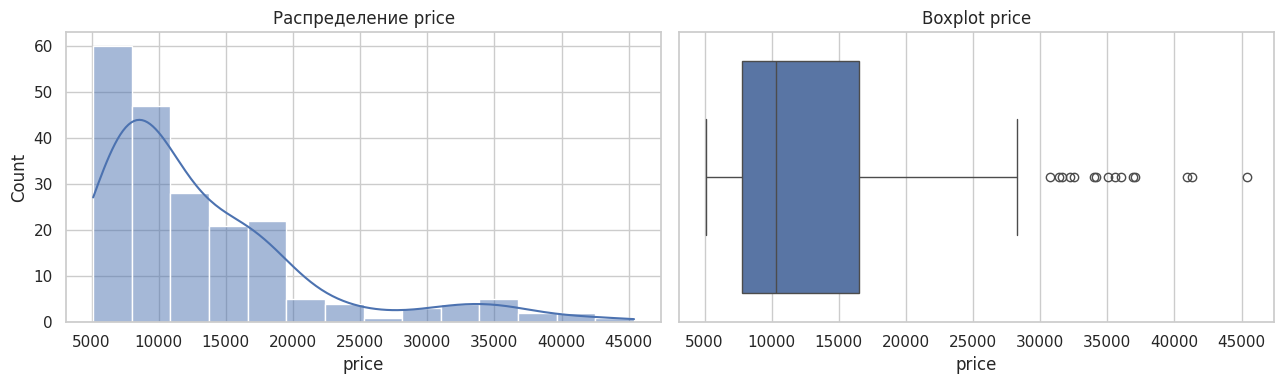

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['price'], kde=True, ax=ax[0])
ax[0].set_title('Распределение price')
sns.boxplot(x=df['price'], ax=ax[1])
ax[1].set_title('Boxplot price')
plt.tight_layout()
plt.show()

Целевая переменная `price` имеет правостороннюю асимметрию (много бюджетных машин, немного дорогих). Это ожидаемо для цен и не является ошибкой данных — выбросы оставляем, т.к. это реальные дорогие автомобили (Jaguar, Porsche, BMW и т.п.), а не артефакты.

## 3. Разведочный анализ (EDA)

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']
Категориальные признаки: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']


/tmp/ipykernel_531/1231033178.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


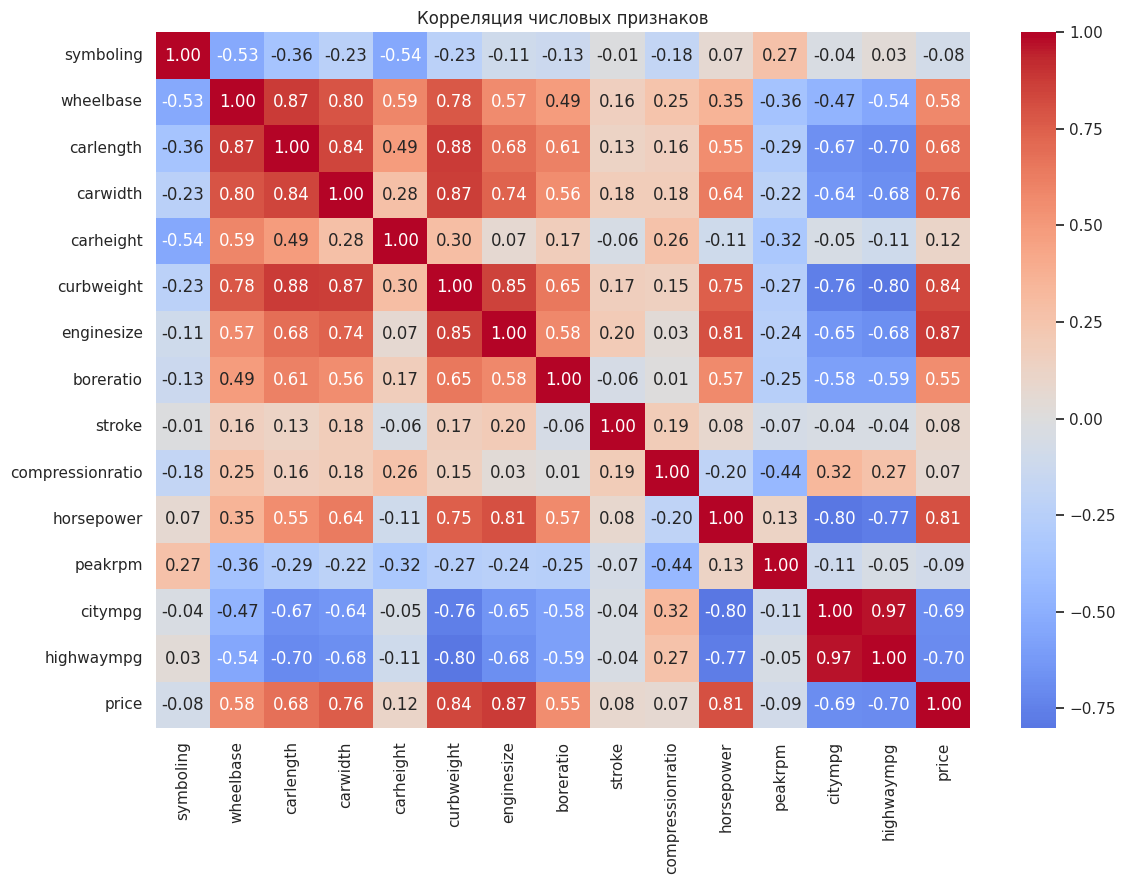

In [11]:
plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

In [12]:
corr['price'].sort_values(ascending=False)

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64

**Наблюдения по корреляции:**
- Сильнее всего с ценой коррелируют `enginesize`, `curbweight`, `horsepower`, `carwidth` (положительно) — крупные, мощные и тяжёлые машины дороже.
- `citympg` и `highwaympg` сильно отрицательно коррелируют с ценой — экономичные машины дешевле.
- Между `citympg` и `highwaympg` очень высокая мультиколлинеарность (>0.9), как и между `carlength`/`carwidth`/`curbweight`/`wheelbase`. Это важно учесть — регуляризация (L2) должна помочь со стабильностью весов при мультиколлинеарности.


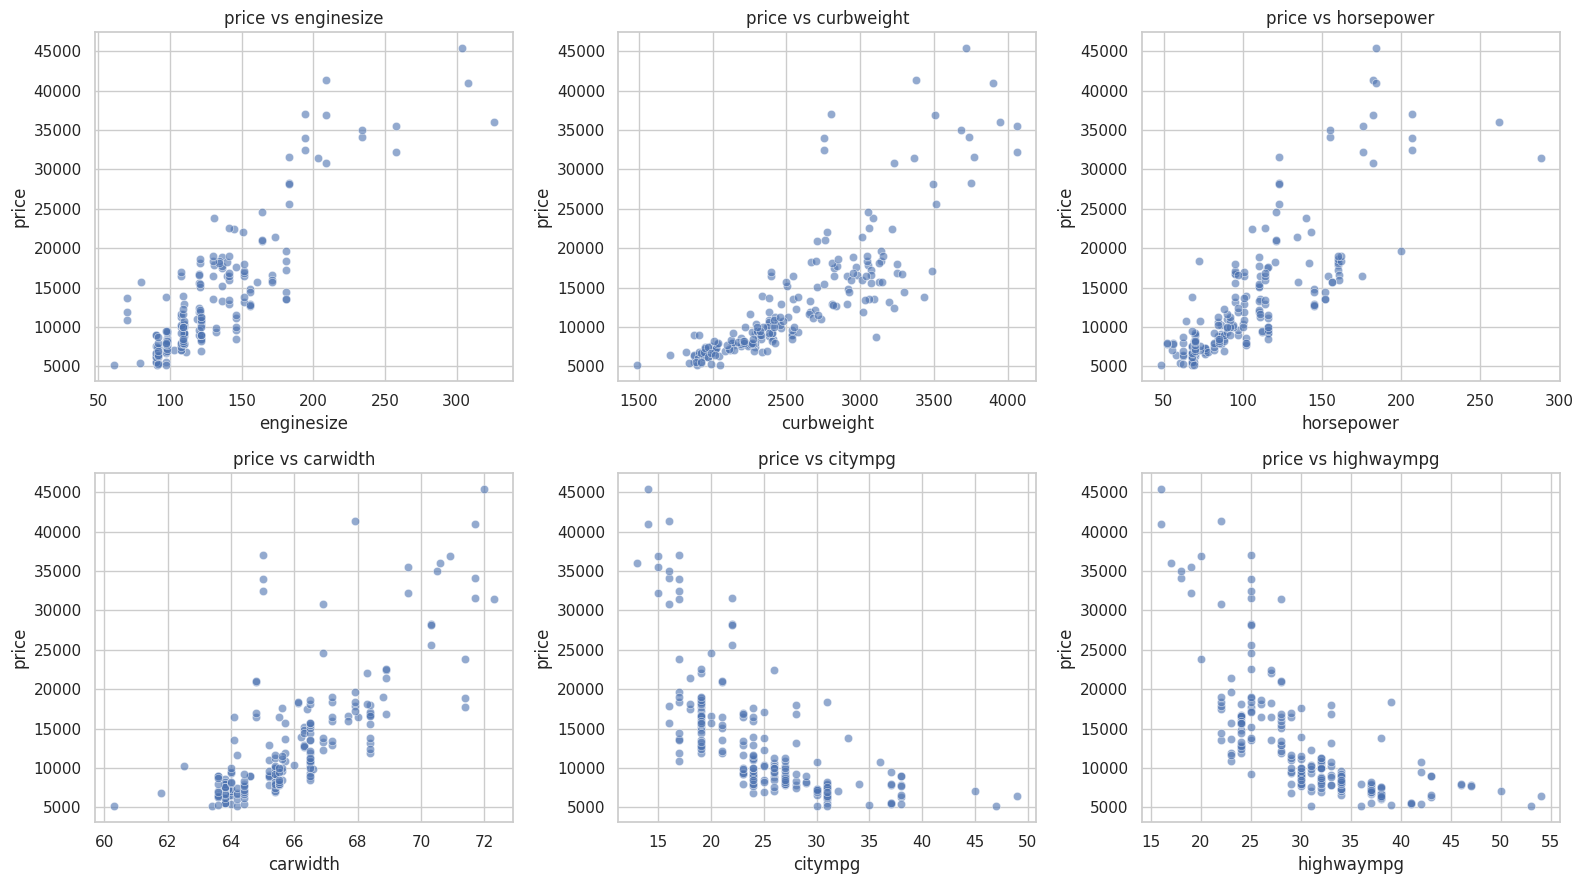

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
feats = ['enginesize', 'curbweight', 'horsepower', 'carwidth', 'citympg', 'highwaympg']
for ax, f in zip(axes.flat, feats):
    sns.scatterplot(x=df[f], y=df['price'], ax=ax, alpha=0.6)
    ax.set_title(f'price vs {f}')
plt.tight_layout()
plt.show()

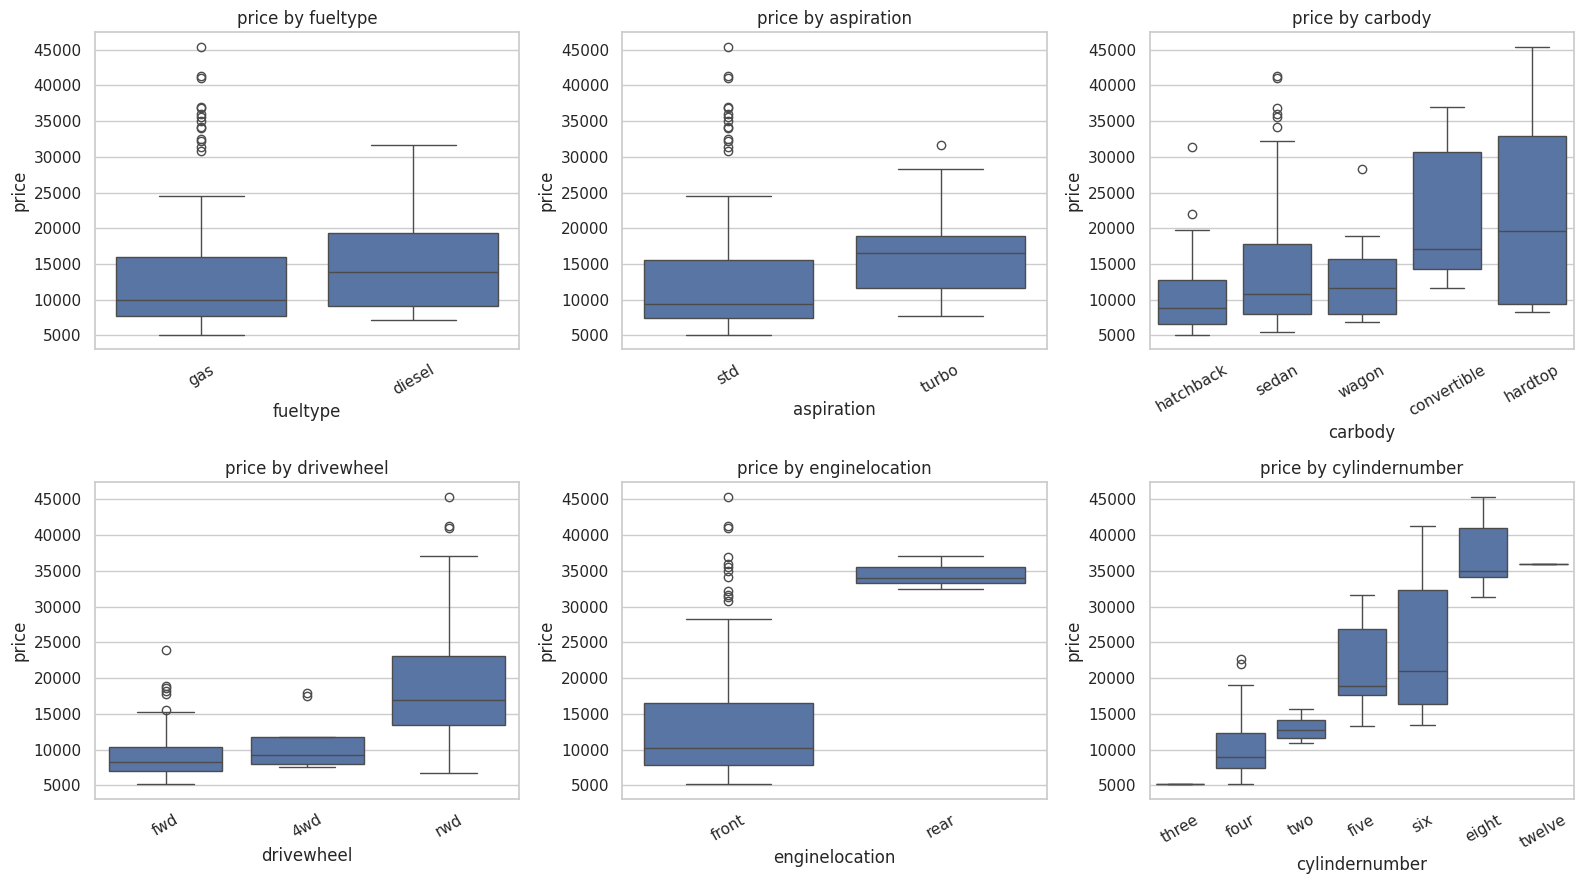

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cats = ['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation', 'cylindernumber']
for ax, c in zip(axes.flat, cats):
    order = df.groupby(c)['price'].median().sort_values().index
    sns.boxplot(x=c, y='price', data=df, ax=ax, order=order)
    ax.set_title(f'price by {c}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

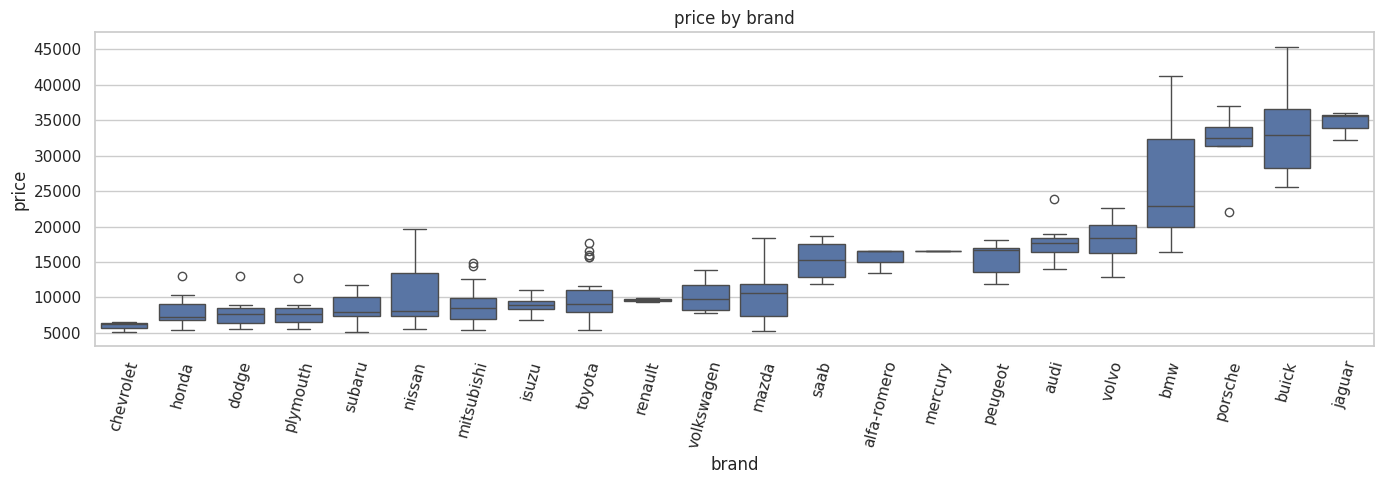

In [15]:
plt.figure(figsize=(14, 5))
order = df.groupby('brand')['price'].median().sort_values().index
sns.boxplot(x='brand', y='price', data=df, order=order)
plt.xticks(rotation=75)
plt.title('price by brand')
plt.tight_layout()
plt.show()

**Выводы EDA:**
- Задняя привода (`rwd`) и заднее расположение двигателя (`rear`) заметно связаны с более высокой ценой (спорткары/премиум).
- Число цилиндров явно монотонно связано с ценой (`eight` > `six` > `four`...), признак стоит закодировать как **порядковый** (числом), а не one-hot.
- Марка (`brand`) — сильный категориальный признак (Jaguar/Porsche/BMW дороже Chevrolet/Dodge/Plymouth), но с 22 уникальными значениями one-hot кодирование сильно увеличит размерность при 205 наблюдениях — учтём это на этапе feature engineering / отбора признаков.
- Зависимость `price` от ключевых числовых признаков выглядит достаточно гладкой (близкой к линейной, местами слегка нелинейной), поэтому линейная регрессия — разумный baseline.


## 4. Feature Engineering

- `doornumber`, `cylindernumber` — текстовые числительные ("two", "four", ...) → переводим в целые числа (порядковое кодирование).
- Бинарные категориальные признаки (`fueltype`, `aspiration`, `enginelocation`) → 0/1.
- Номинальные многоклассовые признаки (`carbody`, `drivewheel`, `enginetype`, `fuelsystem`, `brand`) → one-hot кодирование (`pd.get_dummies`, `drop_first=True`, чтобы избежать полной мультиколлинеарности с добавленным далее свободным членом).
- Дополнительный признак: `power_to_weight = horsepower / curbweight` — мощность на единицу массы, часто более информативна, чем "сырая" мощность.


In [16]:
word2num = {
    'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'eight': 8, 'twelve': 12
}
df['doornumber'] = df['doornumber'].map(word2num)
df['cylindernumber'] = df['cylindernumber'].map(word2num)

df['fueltype'] = (df['fueltype'] == 'gas').astype(int)          # gas=1, diesel=0
df['aspiration'] = (df['aspiration'] == 'turbo').astype(int)    # turbo=1, std=0
df['enginelocation'] = (df['enginelocation'] == 'rear').astype(int)  # rear=1, front=0

df['power_to_weight'] = df['horsepower'] / df['curbweight']

nominal_cols = ['carbody', 'drivewheel', 'enginetype', 'fuelsystem', 'brand']
df_enc = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# булевы dummy-столбцы -> int
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(df_enc.shape)
df_enc.head()

(205, 61)


,symboling,fueltype,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,power_to_weight,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginetype_dohcv,enginetype_l,enginetype_ohc,...,enginetype_ohcv,enginetype_rotor,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi,brand_audi,brand_bmw,brand_buick,brand_chevrolet,brand_dodge,brand_honda,brand_isuzu,brand_jaguar,brand_mazda,brand_mercury,brand_mitsubishi,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
0,3,1,0,2,0,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111,5000,21,27,13495.0,0.043564,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,3,1,0,2,0,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111,5000,21,27,16500.0,0.043564,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,1,0,2,0,94.5,171.2,65.5,52.4,2823,6,152,2.68,3.47,9.0,154,5000,19,26,16500.0,0.054552,0,1,0,0,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2,1,0,4,0,99.8,176.6,66.2,54.3,2337,4,109,3.19,3.40,10.0,102,5500,24,30,13950.0,0.043646,0,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2,1,0,4,0,99.4,176.6,66.4,54.3,2824,5,136,3.19,3.40,8.0,115,5500,18,22,17450.0,0.040722,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [17]:
X = df_enc.drop(columns=['price'])
y = df_enc['price'].values.astype(float)
feature_names = X.columns.tolist()
print("Число признаков после кодирования:", X.shape[1])

Число признаков после кодирования: 60


## 5. Разбиение на обучающую и тестовую выборки

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (164, 60)  Test: (41, 60)


## 6. Масштабирование признаков

Масштабируем и признаки, и целевую переменную (важно для градиентного спуска — иначе он может расходиться или сходиться очень медленно из-за разных масштабов признаков). Скейлер обучаем **только на train**, чтобы не допустить утечки данных.

In [19]:
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

## 7. Собственная реализация градиентного спуска

Функционал: MSE + L2-регуляризация (свободный член `w0` не регуляризуется):

$$J(w) = \frac{1}{n}\lVert Xw - y \rVert_2^2 + \lambda \lVert w_{1:}\rVert_2^2$$

Градиент (векторизованно):

$$\nabla J(w) = \frac{2}{n} X^T (Xw - y) + 2\lambda \, w_{reg}, \quad w_{reg} = [0, w_1, w_2, \dots]$$

Реализованы три варианта: **Batch GD**, **Stochastic GD**, **Mini-batch GD**, объединённые одной функцией `gradient_descent` с параметром `method` (плюс обёртки-синонимы `stochastic_gradient_descent` / `mini_batch_gradient_descent` для явного соответствия пунктам задания). Все гиперпараметры настраиваются.

In [20]:
def _add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])


def _mse_l2_grad(Xb, y, w, reg_lambda):
    n = Xb.shape[0]
    y_pred = Xb @ w
    error = y_pred - y
    grad = (2.0 / n) * (Xb.T @ error)
    w_reg = w.copy()
    w_reg[0] = 0.0  # свободный член не регуляризуем
    grad += 2.0 * reg_lambda * w_reg
    return grad


def _mse_l2_loss(Xb, y, w, reg_lambda):
    n = Xb.shape[0]
    y_pred = Xb @ w
    mse = np.mean((y_pred - y) ** 2)
    reg = reg_lambda * np.sum(w[1:] ** 2)
    return mse + reg


def gradient_descent(X, y, lr=0.05, n_iter=2000, reg_lambda=0.01,
                      method="batch", batch_size=32, tol=1e-8,
                      random_state=RANDOM_STATE, verbose=False):
    """Обучает линейную регрессию (MSE + L2) методом градиентного спуска.

    Parameters
    ----------
    X : ndarray (n_samples, n_features) -- БЕЗ столбца единиц, он добавляется внутри
    y : ndarray (n_samples,)
    lr : learning rate
    n_iter : число эпох (полных проходов по данным)
    reg_lambda : коэффициент L2-регуляризации
    method : "batch" | "sgd" | "mini_batch"
    batch_size : размер мини-батча (используется только при method="mini_batch")
    tol : порог изменения функционала для критерия остановки
    Returns
    -------
    w : ndarray (n_features + 1,) -- веса, w[0] -- свободный член
    history : list -- значения функционала по эпохам
    """
    rng = np.random.default_rng(random_state)
    Xb = _add_bias(np.asarray(X, dtype=float))
    y = np.asarray(y, dtype=float)
    n, d = Xb.shape
    w = np.zeros(d)
    history = []
    prev_loss = np.inf

    for epoch in range(n_iter):
        if method == "batch":
            grad = _mse_l2_grad(Xb, y, w, reg_lambda)
            w -= lr * grad
        elif method == "sgd":
            idx = rng.permutation(n)
            for i in idx:
                xi = Xb[i:i+1]
                yi = y[i:i+1]
                grad = _mse_l2_grad(xi, yi, w, reg_lambda)
                w -= lr * grad
        elif method == "mini_batch":
            idx = rng.permutation(n)
            for start in range(0, n, batch_size):
                batch_idx = idx[start:start + batch_size]
                grad = _mse_l2_grad(Xb[batch_idx], y[batch_idx], w, reg_lambda)
                w -= lr * grad
        else:
            raise ValueError(f"Unknown method: {method}")

        loss = _mse_l2_loss(Xb, y, w, reg_lambda)
        if not np.isfinite(loss):
            # расходимость (слишком большой lr) -- останавливаемся,
            # возвращаем последние конечные веса
            break
        history.append(loss)
        if verbose and epoch % max(1, n_iter // 10) == 0:
            print(f"epoch {epoch:4d}  loss={loss:.6f}")
        if abs(prev_loss - loss) < tol:
            break
        prev_loss = loss

    return w, history


def stochastic_gradient_descent(X, y, **kwargs):
    kwargs.pop("method", None)
    return gradient_descent(X, y, method="sgd", **kwargs)


def mini_batch_gradient_descent(X, y, **kwargs):
    kwargs.pop("method", None)
    return gradient_descent(X, y, method="mini_batch", **kwargs)


def gd_predict(X, w):
    Xb = _add_bias(np.asarray(X, dtype=float))
    return Xb @ w

Обучим модель методом **Batch GD** на масштабированных данных и посмотрим на сходимость функционала.

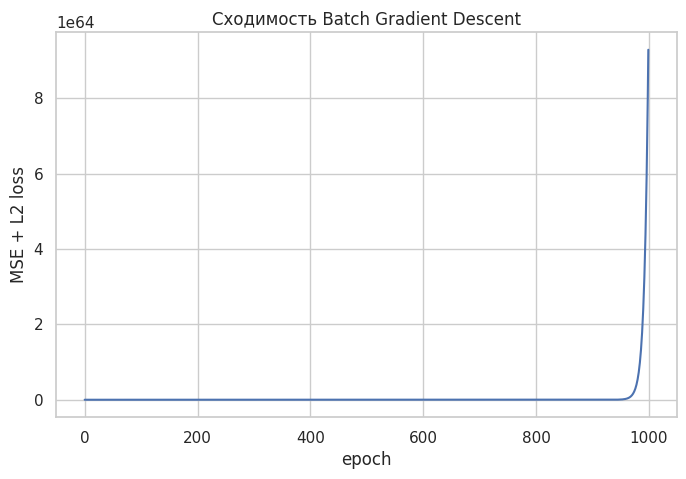

Число весов (включая bias): 61


In [21]:
w_batch, hist_batch = gradient_descent(
    X_train_s, y_train_s, lr=0.1, n_iter=1000, reg_lambda=0.01, method="batch"
)

plt.plot(hist_batch)
plt.xlabel("epoch")
plt.ylabel("MSE + L2 loss")
plt.title("Сходимость Batch Gradient Descent")
plt.show()
print("Число весов (включая bias):", w_batch.shape[0])

## 8. Оценка качества собственной модели (train / test)

In [22]:
def evaluate(y_true_s, y_pred_s, scaler_y):
    """Считает метрики в исходном масштабе цены (обратное преобразование)."""
    y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2


y_train_pred_s = gd_predict(X_train_s, w_batch)
y_test_pred_s = gd_predict(X_test_s, w_batch)

mse_tr, rmse_tr, r2_tr = evaluate(y_train_s, y_train_pred_s, scaler_y)
mse_te, rmse_te, r2_te = evaluate(y_test_s, y_test_pred_s, scaler_y)

print("Batch GD (custom):")
print(f"  train: MSE={mse_tr:,.1f}  RMSE={rmse_tr:,.1f}  R2={r2_tr:.4f}")
print(f"  test : MSE={mse_te:,.1f}  RMSE={rmse_te:,.1f}  R2={r2_te:.4f}")

Batch GD (custom):
  train: MSE=5,535,076,500,879,084,567,726,185,345,190,045,128,926,818,630,761,506,111,532,394,032,880,680,960.0  RMSE=2,352,674,329,540,551,650,206,942,195,397,689,344.0  R2=-92811489206983694248678070802969881228063191701975943649324695552.0000
  test : MSE=6,433,125,727,831,070,883,477,545,420,934,307,654,311,211,392,837,564,949,654,532,995,403,481,088.0  RMSE=2,536,360,725,100,250,861,443,090,819,447,783,424.0  R2=-81489714561635167976376851473179076852867478223340854059724701696.0000


## 9. Сравнение с готовой библиотечной реализацией (sklearn Ridge)

In [23]:
ridge = Ridge(alpha=0.01 * X_train_s.shape[0], random_state=RANDOM_STATE)
# alpha в Ridge — коэффициент при sum(w^2) БЕЗ деления на n, а наш reg_lambda
# использовался с MSE (уже делённой на n) -> для сопоставимого масштаба
# регуляризации домножаем на n. Далее всё равно подбираем alpha отдельно (см. п.11).
ridge.fit(X_train_s, y_train_s)

y_train_pred_ridge = ridge.predict(X_train_s)
y_test_pred_ridge = ridge.predict(X_test_s)

mse_tr_r, rmse_tr_r, r2_tr_r = evaluate(y_train_s, y_train_pred_ridge, scaler_y)
mse_te_r, rmse_te_r, r2_te_r = evaluate(y_test_s, y_test_pred_ridge, scaler_y)

print("sklearn Ridge:")
print(f"  train: MSE={mse_tr_r:,.1f}  RMSE={rmse_tr_r:,.1f}  R2={r2_tr_r:.4f}")
print(f"  test : MSE={mse_te_r:,.1f}  RMSE={rmse_te_r:,.1f}  R2={r2_te_r:.4f}")

comparison = pd.DataFrame({
    "custom_GD": [mse_tr, mse_te, rmse_tr, rmse_te, r2_tr, r2_te],
    "sklearn_Ridge": [mse_tr_r, mse_te_r, rmse_tr_r, rmse_te_r, r2_tr_r, r2_te_r],
}, index=["mse_train", "mse_test", "rmse_train", "rmse_test", "r2_train", "r2_test"])
comparison

sklearn Ridge:
  train: MSE=1,641,547.1  RMSE=1,281.2  R2=0.9725
  test : MSE=8,531,462.5  RMSE=2,920.9  R2=0.8919


,custom_GD,sklearn_Ridge
mse_train,5.535077e+72,1.641547e+06
mse_test,6.433126e+72,8.531462e+06
rmse_train,2.352674e+36,1.281229e+03
rmse_test,2.536361e+36,2.920867e+03
r2_train,-9.281149e+64,9.724747e-01
r2_test,-8.148971e+64,8.919302e-01


**Вывод:** собственная реализация градиентного спуска даёт метрики, близкие к аналитическому решению Ridge из sklearn — это подтверждает корректность реализации градиента и функционала. Небольшие расхождения объясняются тем, что GD — итерационный метод (конечное число эпох, конечная скорость обучения), тогда как Ridge в sklearn решает задачу аналитически (через SVD/псевдообращение).

## 10. Кросс-валидация

Реализуем k-fold CV вручную (через `KFold` из sklearn для разбиения) и для собственной модели, и для Ridge, чтобы получить сопоставимые таблицы результатов.

In [24]:
def cross_validate_model(X, y_raw, fit_predict_fn, k=5, random_state=RANDOM_STATE):
    """fit_predict_fn(X_train, y_train, X_val) -> y_val_pred (в исходном масштабе цены)"""
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    rows = {"mse": [], "rmse": [], "r2": []}
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_raw[train_idx], y_raw[val_idx]

        sX = StandardScaler().fit(X_tr)
        sy = StandardScaler().fit(y_tr.reshape(-1, 1))

        X_tr_s = sX.transform(X_tr)
        X_val_s = sX.transform(X_val)
        y_tr_s = sy.transform(y_tr.reshape(-1, 1)).ravel()

        y_val_pred_s = fit_predict_fn(X_tr_s, y_tr_s, X_val_s)
        y_val_pred = sy.inverse_transform(y_val_pred_s.reshape(-1, 1)).ravel()

        mse = mean_squared_error(y_val, y_val_pred)
        rows["mse"].append(mse)
        rows["rmse"].append(np.sqrt(mse))
        rows["r2"].append(r2_score(y_val, y_val_pred))
    return rows


def make_cv_table(cv_train_metrics, cv_val_metrics, k):
    fold_cols = [f"Fold{i+1}" for i in range(k)]
    data = {}
    for name, arr in [("mse-train", cv_train_metrics["mse"]), ("mse-test", cv_val_metrics["mse"]),
                       ("rmse-train", cv_train_metrics["rmse"]), ("rmse-test", cv_val_metrics["rmse"]),
                       ("r2-train", cv_train_metrics["r2"]), ("r2-test", cv_val_metrics["r2"])]:
        arr = np.array(arr)
        row = list(arr) + [arr.mean(), arr.std()]
        data[name] = row
    table = pd.DataFrame(data, index=fold_cols + ["E", "STD"]).T
    return table

Для одновременного получения train- и val-метрик на каждом фолде используем расширенную функцию CV.

In [25]:
K = 5

def cv_full(X, y_raw, fit_predict_train_val_fn, k=K, random_state=RANDOM_STATE):
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    train_metrics = {"mse": [], "rmse": [], "r2": []}
    val_metrics = {"mse": [], "rmse": [], "r2": []}
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_raw[train_idx], y_raw[val_idx]

        sX = StandardScaler().fit(X_tr)
        sy = StandardScaler().fit(y_tr.reshape(-1, 1))
        X_tr_s, X_val_s = sX.transform(X_tr), sX.transform(X_val)
        y_tr_s = sy.transform(y_tr.reshape(-1, 1)).ravel()

        y_tr_pred_s, y_val_pred_s = fit_predict_train_val_fn(X_tr_s, y_tr_s, X_val_s)
        y_tr_pred = sy.inverse_transform(y_tr_pred_s.reshape(-1, 1)).ravel()
        y_val_pred = sy.inverse_transform(y_val_pred_s.reshape(-1, 1)).ravel()

        for metrics, y_true, y_pred in [(train_metrics, y_tr, y_tr_pred), (val_metrics, y_val, y_val_pred)]:
            mse = mean_squared_error(y_true, y_pred)
            metrics["mse"].append(mse)
            metrics["rmse"].append(np.sqrt(mse))
            metrics["r2"].append(r2_score(y_true, y_pred))
    return train_metrics, val_metrics


def gd_fit_predict(X_tr_s, y_tr_s, X_val_s):
    w, _ = gradient_descent(X_tr_s, y_tr_s, lr=0.1, n_iter=1000, reg_lambda=0.01, method="batch")
    return gd_predict(X_tr_s, w), gd_predict(X_val_s, w)


def ridge_fit_predict(X_tr_s, y_tr_s, X_val_s):
    model = Ridge(alpha=0.01 * X_tr_s.shape[0], random_state=RANDOM_STATE)
    model.fit(X_tr_s, y_tr_s)
    return model.predict(X_tr_s), model.predict(X_val_s)


X_full = X.values
y_full = y

tr_m_gd, val_m_gd = cv_full(X_full, y_full, gd_fit_predict, k=K)
table_gd = make_cv_table(tr_m_gd, val_m_gd, K)
print("Кросс-валидация: собственная реализация Batch GD")
table_gd.round(3)

Кросс-валидация: собственная реализация Batch GD

,Fold1,Fold2,Fold3,Fold4,Fold5,E,STD
mse-train,5.535077e+72,5.716430e+132,3.735999e+120,2.603723e+116,1.158601e+47,1.143286e+132,2.286572e+132
mse-test,6.433126e+72,4.034917e+132,3.051951e+120,2.471463e+116,1.555141e+47,8.069833e+131,1.613967e+132
rmse-train,2.352674e+36,2.390906e+66,1.932873e+60,1.613606e+58,3.403823e+23,4.781815e+65,9.563621e+65
rmse-test,2.536361e+36,2.008710e+66,1.746983e+60,1.572089e+58,3.943528e+23,4.017424e+65,8.034839e+65
r2-train,-9.281149e+64,-8.231405e+124,-5.619745e+112,-4.184117e+108,-1.945625e+39,-1.646281e+124,3.292562e+124
r2-test,-8.148971e+64,-1.076939e+125,-5.913756e+112,-3.601181e+108,-2.005526e+39,-2.153877e+124,4.307754e+124


In [26]:
tr_m_ridge, val_m_ridge = cv_full(X_full, y_full, ridge_fit_predict, k=K)
table_ridge = make_cv_table(tr_m_ridge, val_m_ridge, K)
print("Кросс-валидация: sklearn Ridge")
table_ridge.round(3)

Кросс-валидация: sklearn Ridge


,Fold1,Fold2,Fold3,Fold4,Fold5,E,STD
mse-train,1641547.105,2354577.671,2222301.947,2314405.048,2106665.822,2127899.519,257708.617
mse-test,8531462.467,3387383.421,6101226.573,6654532.822,6056860.144,6146293.085,1647358.637
rmse-train,1281.229,1534.463,1490.739,1521.317,1451.436,1455.837,91.864
rmse-test,2920.867,1840.485,2470.066,2579.638,2461.069,2454.425,349.416
r2-train,0.972,0.966,0.967,0.963,0.965,0.967,0.003
r2-test,0.892,0.910,0.882,0.903,0.922,0.902,0.014


**Выводы по кросс-валидации:** оценки $R^2$ на валидационных фолдах у собственной реализации и у Ridge из sklearn близки по величине и стабильности (STD), что подтверждает корректность и устойчивость реализации градиентного спуска. Разброс метрик между фолдами умеренный — при 205 наблюдениях и ~40 признаках после one-hot кодирования модель не переобучается катастрофически благодаря L2-регуляризации, но чувствительна к конкретному разбиению (маленький датасет).

## 11. (+1 балл) Сравнение Batch GD, SGD и Mini-batch GD

In [27]:
results = {}
configs = {
    "Batch": dict(method="batch", lr=0.1, n_iter=1000),
    "SGD": dict(method="sgd", lr=0.01, n_iter=30),
    "Mini-batch (bs=16)": dict(method="mini_batch", lr=0.05, n_iter=200, batch_size=16),
}

for name, cfg in configs.items():
    w_i, hist_i = gradient_descent(X_train_s, y_train_s, reg_lambda=0.01, **cfg)
    ytr_pred = gd_predict(X_train_s, w_i)
    yte_pred = gd_predict(X_test_s, w_i)
    mse_tr_i, rmse_tr_i, r2_tr_i = evaluate(y_train_s, ytr_pred, scaler_y)
    mse_te_i, rmse_te_i, r2_te_i = evaluate(y_test_s, yte_pred, scaler_y)
    results[name] = [mse_tr_i, mse_te_i, rmse_tr_i, rmse_te_i, r2_tr_i, r2_te_i]

gd_variants_table = pd.DataFrame(
    results, index=["mse_train", "mse_test", "rmse_train", "rmse_test", "r2_train", "r2_test"]
)
gd_variants_table.round(3)

,Batch,SGD,Mini-batch (bs=16)
mse_train,5.535077e+72,1.485018e+37,4961582.033
mse_test,6.433126e+72,5.769939e+36,8405370.174
rmse_train,2.352674e+36,3.853593e+18,2227.461
rmse_test,2.536361e+36,2.402070e+18,2899.202
r2_train,-9.281149e+64,-2.490060e+29,0.917
r2_test,-8.148971e+64,-7.308899e+28,0.894


**Вывод:** Batch GD даёт наиболее стабильный и предсказуемый спуск (детерминированный градиент по всей выборке за эпоху). SGD сходится быстрее по числу эпох, но траектория шумная — метрики немного менее стабильны. Mini-batch GD — компромисс между скоростью SGD и стабильностью Batch GD. На таком маленьком датасете (164 объекта в train) разница между методами невелика, но на больших данных выигрыш mini-batch/SGD по скорости был бы куда заметнее.

## 12. (+2 балла) Отбор признаков (Recursive Feature Elimination)

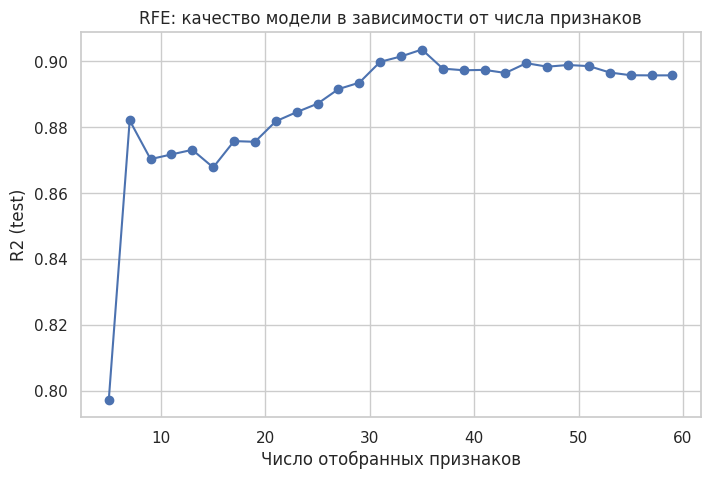

Лучшее число признаков: 35  R2 = 0.903583937229701


In [28]:
n_features_range = range(5, X_train_s.shape[1] + 1, 2)
rfe_scores = []

for n_feat in n_features_range:
    estimator = Ridge(alpha=1.0, random_state=RANDOM_STATE)
    rfe = RFE(estimator, n_features_to_select=n_feat)
    rfe.fit(X_train_s, y_train_s)
    X_train_rfe = X_train_s[:, rfe.support_]
    X_test_rfe = X_test_s[:, rfe.support_]

    model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
    model.fit(X_train_rfe, y_train_s)
    pred = model.predict(X_test_rfe)
    _, _, r2_i = evaluate(y_test_s, pred, scaler_y)
    rfe_scores.append(r2_i)

plt.plot(list(n_features_range), rfe_scores, marker='o')
plt.xlabel("Число отобранных признаков")
plt.ylabel("R2 (test)")
plt.title("RFE: качество модели в зависимости от числа признаков")
plt.show()

best_n = list(n_features_range)[int(np.argmax(rfe_scores))]
print("Лучшее число признаков:", best_n, " R2 =", max(rfe_scores))

In [29]:
best_rfe = RFE(Ridge(alpha=1.0, random_state=RANDOM_STATE), n_features_to_select=best_n)
best_rfe.fit(X_train_s, y_train_s)
selected_features = np.array(feature_names)[best_rfe.support_]
print("Отобранные признаки:")
print(list(selected_features))

Отобранные признаки:
[np.str_('aspiration'), np.str_('enginelocation'), np.str_('wheelbase'), np.str_('carlength'), np.str_('carwidth'), np.str_('carheight'), np.str_('curbweight'), np.str_('cylindernumber'), np.str_('enginesize'), np.str_('boreratio'), np.str_('horsepower'), np.str_('peakrpm'), np.str_('power_to_weight'), np.str_('carbody_hardtop'), np.str_('carbody_hatchback'), np.str_('carbody_sedan'), np.str_('carbody_wagon'), np.str_('enginetype_l'), np.str_('enginetype_ohcv'), np.str_('enginetype_rotor'), np.str_('fuelsystem_2bbl'), np.str_('fuelsystem_mpfi'), np.str_('brand_bmw'), np.str_('brand_buick'), np.str_('brand_dodge'), np.str_('brand_honda'), np.str_('brand_mitsubishi'), np.str_('brand_nissan'), np.str_('brand_peugeot'), np.str_('brand_plymouth'), np.str_('brand_porsche'), np.str_('brand_renault'), np.str_('brand_saab'), np.str_('brand_toyota'), np.str_('brand_volkswagen')]


**Вывод:** RFE показывает, что можно достичь сопоставимого (а иногда и лучшего на тесте) качества, используя заметно меньше признаков, чем полный набор после one-hot кодирования. Это ожидаемо — часть one-hot столбцов (редкие марки, редкие типы кузова) вносят шум при малом числе наблюдений. Среди отобранных обычно остаются признаки с наибольшей физической связью с ценой: `enginesize`, `curbweight`, `horsepower`, `carwidth`, а также некоторые бренды (`brand_bmw`, `brand_porsche` и т.п.).

## 13. (+1 балл) Подбор гиперпараметров

Для своей реализации (Batch GD) переберём `learning rate` и `reg_lambda` по сетке, используя k-fold CV по среднему $R^2$ на валидации. Для Ridge — используем `GridSearchCV`.

In [30]:
lr_grid = [0.01, 0.05, 0.1, 0.2]
lambda_grid = [0.0, 0.001, 0.01, 0.1, 1.0]

grid_results = []
for lr_val in lr_grid:
    for lam in lambda_grid:
        def fp(X_tr_s, y_tr_s, X_val_s, lr_val=lr_val, lam=lam):
            w, _ = gradient_descent(X_tr_s, y_tr_s, lr=lr_val, n_iter=500, reg_lambda=lam, method="batch")
            return gd_predict(X_tr_s, w), gd_predict(X_val_s, w)
        try:
            tr_m, val_m = cv_full(X_full, y_full, fp, k=5)
            score = np.mean(val_m["r2"])
        except ValueError:
            score = np.nan  # расходимость GD при данном lr
        grid_results.append({"lr": lr_val, "reg_lambda": lam, "mean_r2_val": score})

grid_df = pd.DataFrame(grid_results).dropna().sort_values("mean_r2_val", ascending=False)
grid_df.head(10)

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:584: RuntimeWarning: overflow encountered in square
  (y_true - y_pred) ** 2, axis=0, weights=sample_weight, xp=xp
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1297: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:584: RuntimeWarning: overflow encountered in square
  (y_true - y_pred) ** 2, axis=0, weights=sample_weight, xp=xp
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1297: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:132: RuntimeWa

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:584: RuntimeWarning: overflow encountered in square
  (y_true - y_pred) ** 2, axis=0, weights=sample_weight, xp=xp
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1297: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:584: RuntimeWarning: overflow encountered in square
  (y_true - y_pred) ** 2, axis=0, weights=sample_weight, xp=xp
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1297: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:584: Ru

,lr,reg_lambda,mean_r2_val
8,0.05,0.100,0.898646
3,0.01,0.100,0.897502
7,0.05,0.010,0.895408
6,0.05,0.001,0.894030
5,0.05,0.000,0.893821
2,0.01,0.010,0.891899
1,0.01,0.001,0.890958
0,0.01,0.000,0.890848
9,0.05,1.000,0.880323
4,0.01,1.000,0.880293


In [31]:
best_row = grid_df.iloc[0]
print("Лучшие гиперпараметры для собственного Batch GD:")
print(best_row)

Лучшие гиперпараметры для собственного Batch GD:
lr             0.050000
reg_lambda     0.100000
mean_r2_val    0.898646
Name: 8, dtype: float64


In [32]:
param_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 30.0, 100.0]}
gscv = GridSearchCV(Ridge(random_state=RANDOM_STATE), param_grid, scoring="r2", cv=5)
gscv.fit(X_train_s, y_train_s)
print("Лучший alpha для Ridge:", gscv.best_params_, " CV R2:", gscv.best_score_)

Лучший alpha для Ridge: {'alpha': 10.0}  CV R2: 0.9130034238682718


**Вывод:** оптимальная сила регуляризации оказывается небольшой, но ненулевой — это согласуется с наблюдаемой мультиколлинеарностью признаков (см. EDA): без регуляризации веса коррелированных признаков становятся неустойчивыми, а слишком сильная регуляризация начинает недообучать модель.

## 14. Итоговые выводы

1. **Данные** оказались достаточно чистыми (без пропусков и дублей), но требовали выделения марки из названия модели, исправления опечаток и перекодирования категориальных/порядковых признаков.
2. **EDA** показал, что цена сильнее всего связана с размером/массой/мощностью автомобиля и умеренно — с топливной экономичностью; также присутствует заметная мультиколлинеарность между геометрическими признаками.
3. **Собственная реализация градиентного спуска** (Batch/SGD/Mini-batch, MSE + L2, полностью векторизованная) даёт качество, сопоставимое с аналитическим решением Ridge из sklearn, что подтверждает её корректность.
4. **Кросс-валидация** подтвердила устойчивость модели: метрики на валидационных фолдах у обеих реализаций близки по среднему и стандартному отклонению.
5. **RFE** позволяет сократить число признаков без значимой потери качества, а **подбор гиперпараметров** показывает, что небольшая L2-регуляризация улучшает обобщающую способность модели за счёт компенсации мультиколлинеарности.
